# Análisis de la varianza molecular (AMOVA) 

Implementacion en python de [AMOVA](https://www.frontiersin.org/journals/ecology-and-evolution/articles/10.3389/fevo.2018.00066/full)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from itertools import combinations, product
from collections import Counter
import random
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx

## Exploracion

In [2]:
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
RESULTS_DIR = Path("../results/amova")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
COORDS_PATH = DATA_PROCESSED / "accessions_coordinates.csv"
assert COORDS_PATH.is_file(), f"No existe {COORDS_PATH}"

In [3]:
coords_df = pd.read_csv(COORDS_PATH)
coords_df[["latitude","longitude"]].head()

,latitude,longitude
0,35.182917,-115.846222
1,35.205444,-115.870861
2,35.195550,-115.858733
3,35.195467,-115.858000
4,35.199550,-115.869467


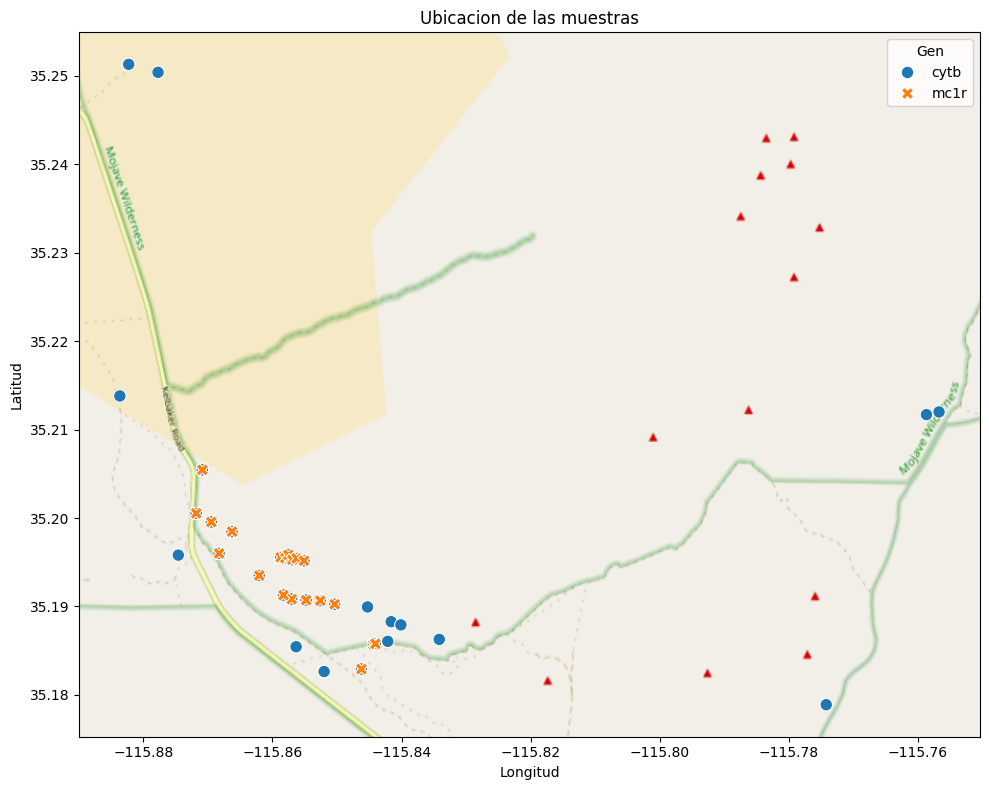

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(data=coords_df, x='longitude', y='latitude',
                hue='gene', style='gene', s=80, ax=ax)

# Add OpenStreetMap basemap (requires internet)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik,
                attribution=False)  # set to True to show attribution in figure
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Ubicacion de las muestras')
ax.legend(title='Gen')
plt.tight_layout()
plt.show()

Como se puede observar todas las secuencias estan alredor del Desierto de Mojave en California, US.

In [5]:
coords_df['gene'] = coords_df['gene'].str.replace("cytochrome b",'cytb')
coords_df['gene'] = coords_df['gene'].str.replace("melanocortin 1 receptor",'mc1r')

In [ ]:
def populations_from_coords(coords_df, gene_of_interest = 'cytb'):
    gene_df = coords_df[coords_df['gene'] == gene_of_interest].copy()
    coords = gene_df[['longitude', 'latitude']].values

    degrees_range = gene_df[['longitude', 'latitude']].aggregate(['min','max']).T
    max_degrees = (degrees_range['max']-degrees_range['min']).max()

    geo_dist = pdist(coords)
    Z = linkage(geo_dist, method='complete')
    # Grados, ajustar segun la escala total, actualmente heusrisica segun dispersion
    threshold =  max_degrees/3 # sqrt or log, en np.log(len(gene_df))
    gene_df['population'] = fcluster(Z, threshold, criterion='distance')
    gene_df['population'] =  gene_df['population'].astype(str)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(data=gene_df, x='longitude', y='latitude',
                    hue='population', palette='tab10', s=100, edgecolor='black', ax=ax)

    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik,
                    attribution=False)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_title(f'Clusters geograficos para {gene_of_interest}\n(separacion = {threshold}°)')
    ax.legend(title='Poblacion', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return gene_df[['id', 'population']]

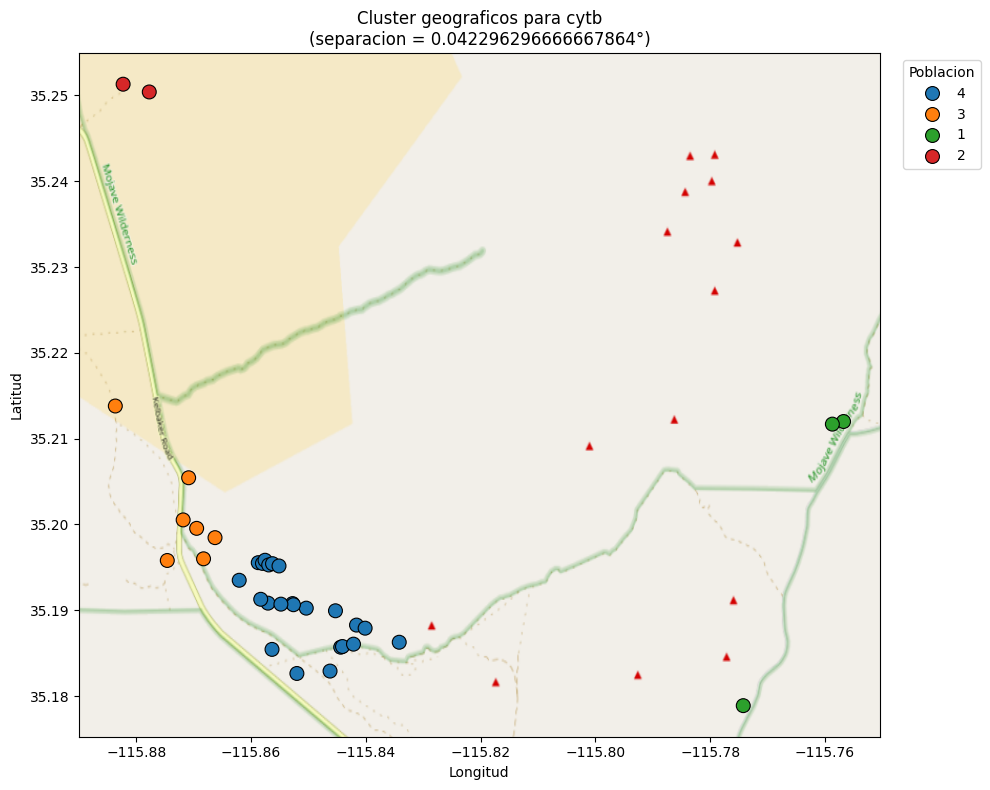

,id,population
0,KR026343,4
1,KR026344,3
2,KR026345,4
3,KR026346,4
4,KR026347,3
5,KR026348,4
6,KR026349,4
7,KR026350,3
8,KR026351,4
9,KR026352,4


In [54]:
populations_from_coords(coords_df,"cytb")

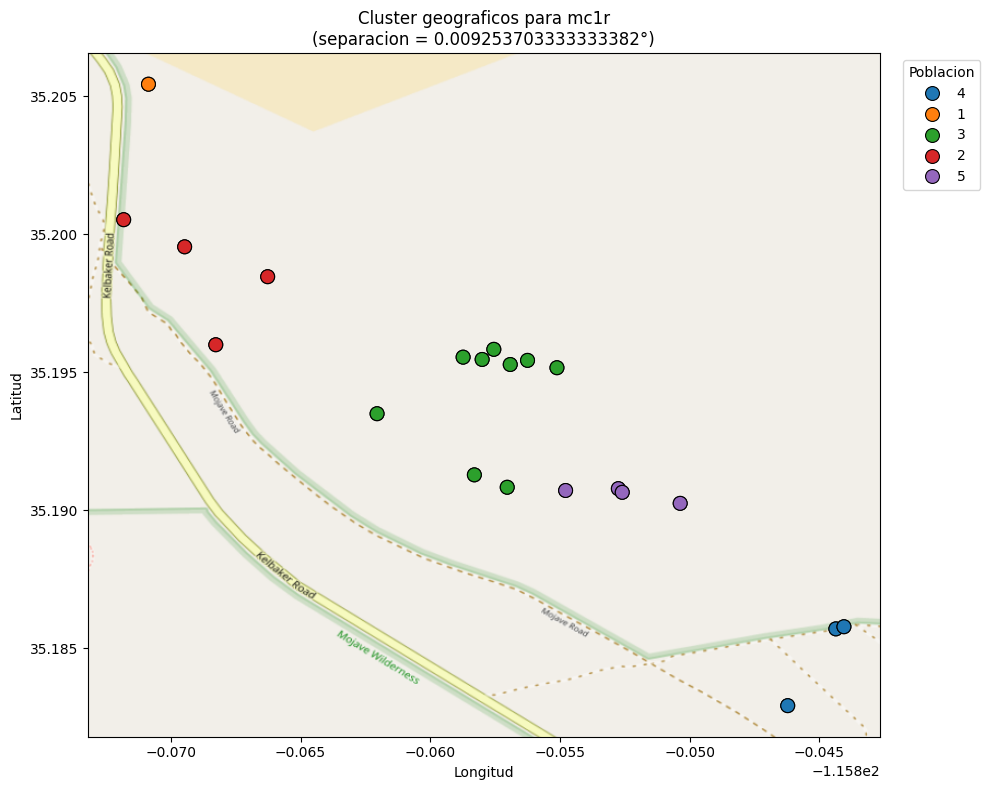

,id,population
35,KR026455,4
36,KR026456,4
37,KR026457,1
38,KR026458,1
39,KR026459,3
40,KR026460,3
41,KR026461,3
42,KR026462,3
43,KR026463,2
44,KR026464,2


In [55]:
populations_from_coords(coords_df,"mc1r")

## Funciones de ayuda

### Distancias

In [9]:
def hamming_distance(seq1, seq2):
    """
    Distancia de Hamming (modificacion de caracteres en cadenas de texto)
    """
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

def kmer_distance(seq1, seq2, k=4):
    """
    Distancia euclidiana entre vectores de frecuencia de k-meros.
    Tambien funciona para sequencias de diferente longitud
    """
    return np.linalg.norm(seq1 - seq2)

def compute_distance_matrix(X, metric='euclidean'):
    """
    Aplica la distancia entre cada 2 secuencias de una lista dada
    method: 'hamming' (requiere misma longitud) or 'kmer'
    """
    n = X.shape[0]
    D = np.zeros((n, n))
    if metric == 'euclidean':
        for i, j in combinations(range(n), 2):
            d = np.linalg.norm(X[i] - X[j])
            D[i, j] = D[j, i] = d
    elif metric == 'cosine':
        D = cosine_distances(X)
    elif metric == 'manhattan':
        for i, j in combinations(range(n), 2):
            d = np.sum(np.abs(X[i] - X[j]))
            D[i, j] = D[j, i] = d
    else:
        raise ValueError("metric must be 'euclidean', 'cosine', or 'manhattan'")
    return D


### AMOVA

In [10]:
def amova_from_distance_matrix(D, groups):
    """
    D : matriz de distancias (n_samples x n_samples)
    groups : lista de etiquetas de grupo (length n_samples)
    Returns dict with:
        'ss_total', 'ss_among', 'ss_within',
        'ms_among', 'ms_within',
        'var_among', 'var_within',
        'phi_st', 'p_value' (if permutations > 0)
    """
    groups = np.array(groups)
    unique_groups = np.unique(groups)
    n = D.shape[0]
    
    D2 = D ** 2
    
    #  Escalamiento
    SS_total = np.sum(D2) / n
    
    # Suma de cuadrados en el grupo
    SS_within = 0.0
    for g in unique_groups:
        idx = np.where(groups == g)[0]
        n_g = len(idx)
        if n_g < 2:
            continue
        subD2 = D2[np.ix_(idx, idx)]
        SS_within += np.sum(subD2) / n_g
    SS_within = SS_within / 2  
    
    # Suma de cuadrados entre grupos
    SS_among = SS_total - SS_within
    
    # Grados de libertad
    df_total = n - 1
    df_among = len(unique_groups) - 1
    df_within = df_total - df_among
    
    # Promedio de cuadrados
    MS_among = SS_among / df_among if df_among > 0 else 0
    MS_within = SS_within / df_within if df_within > 0 else 0
    
    # Varianza
    n_i = [np.sum(groups == g) for g in unique_groups]
    n_prime = (n**2 - np.sum(np.array(n_i)**2)) / (df_among * n)
    var_among = (MS_among - MS_within) / n_prime if n_prime > 0 else 0
    var_within = MS_within
    
    # Phi-estadistico
    phi_st = var_among / (var_among + var_within) if (var_among + var_within) > 0 else 0

    results = {
        'Suma de cuadrados total': [SS_total],
        'Suma de cuadrados entre grupos': [SS_among],
        'Suma de cuadrados entre individuos': [SS_within],
        'Grados de libertad de grupos': [df_among],
        'Grados de libertad de individuos': [df_within],
        'Media cuadrada entre grupos': [MS_among],
        'Media cuadrada entre individuos': [MS_within],
        'Variacion entre grupos': [var_among],
        'Variacion entre individuos': [var_within],
        'phi_st': [phi_st]
    }
    
    return results

def permutation_test_amova(D, groups, n_permutations=999):
    """
    Aplica un test de permutacion para obtener la significancia de Phi_ST.
    """
    observed = amova_from_distance_matrix(D, groups)['phi_st']
    permuted_phis = []
    groups = np.array(groups)
    for _ in range(n_permutations):
        perm_groups = np.random.permutation(groups)
        perm_phi = amova_from_distance_matrix(D, perm_groups)['phi_st']
        permuted_phis.append(perm_phi)
    # p-value: proporcion de phi permutados >= observed
    p_value = (np.sum(np.array(permuted_phis) >= observed) + 1) / (n_permutations + 1)
    return p_value

In [29]:
def analisis(file="mc1r"):
    ids_df = pd.read_csv(f"../data/processed/{file}_encoded.csv") 
    df = pd.read_csv(f"../data/processed/{file}_4mers.csv")
    df['id'] = ids_df['id']
    populations = populations_from_coords(coords_df,file)
    df = pd.merge(df,populations,on='id',how='inner').sort_values("population")
    #print(df[['population']])
    df = df.drop('id',axis=1)
    X = df.drop('population', axis=1).values.astype(float)
    groups = df['population'].values
    #print(groups)
    D = compute_distance_matrix(X)
    sns.heatmap(D)

    results = amova_from_distance_matrix(D, groups)
    p_val = permutation_test_amova(D, groups, n_permutations=999)
    results['p_value'] = p_val

    print(f"=== Resultados de AMOVA  ({file}) ===")
    return pd.DataFrame(results)

## Aplicacion

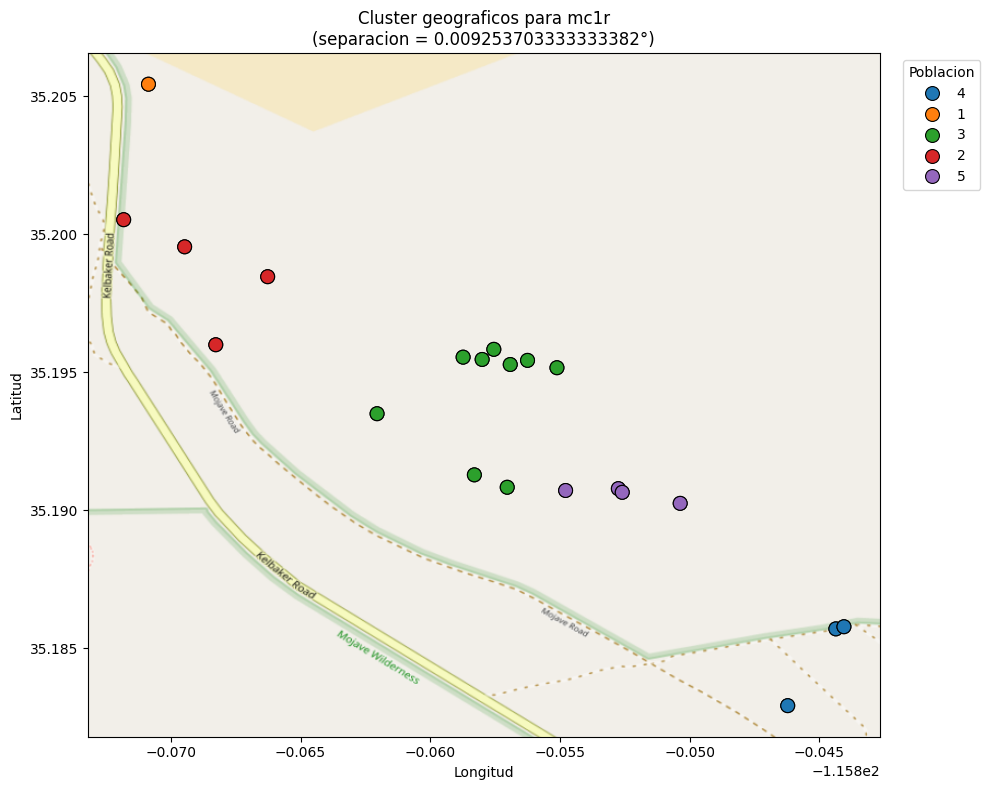

=== Resultados de AMOVA  (mc1r) ===


,Suma de cuadrados total,Suma de cuadrados entre grupos,Suma de cuadrados entre individuos,Grados de libertad de grupos,Grados de libertad de individuos,Media cuadrada entre grupos,Media cuadrada entre individuos,Variacion entre grupos,Variacion entre individuos,phi_st,p_value
0,0.002154,0.001179,0.000975,4,37,0.000295,0.000026,0.000035,0.000026,0.573666,0.493


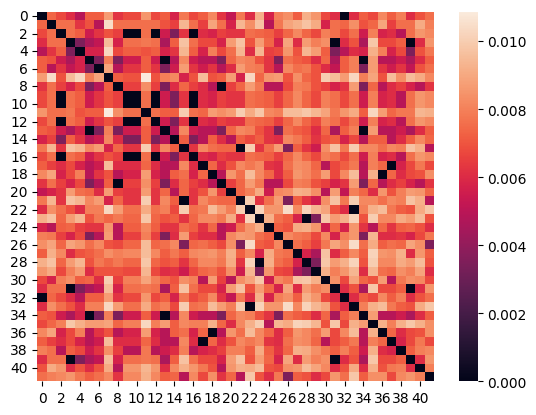

In [56]:
analisis("mc1r")

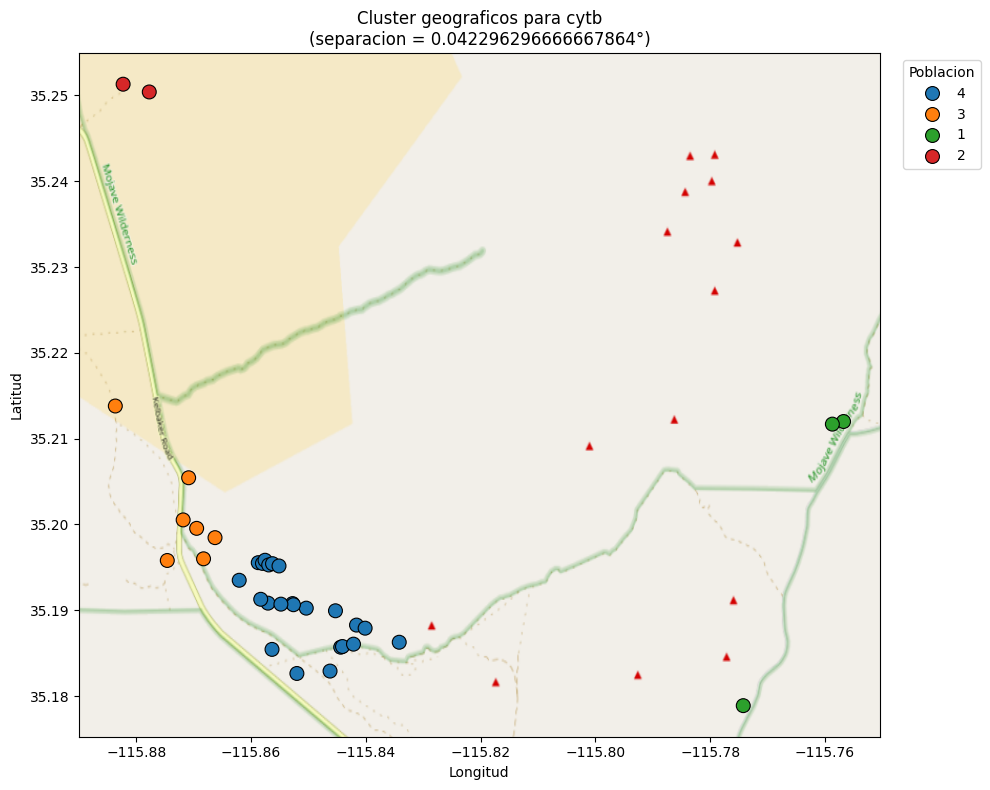

=== Resultados de AMOVA  (cytb) ===


,Suma de cuadrados total,Suma de cuadrados entre grupos,Suma de cuadrados entre individuos,Grados de libertad de grupos,Grados de libertad de individuos,Media cuadrada entre grupos,Media cuadrada entre individuos,Variacion entre grupos,Variacion entre individuos,phi_st,p_value
0,0.001671,0.000941,0.00073,3,31,0.000314,0.000024,0.000048,0.000024,0.671073,0.112


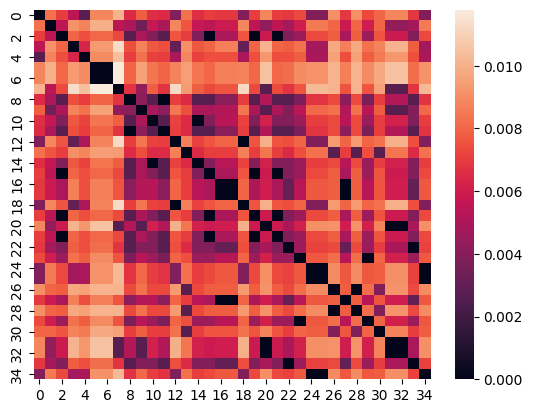

In [57]:
analisis("cytb")

- **Suma de cuadrados total** es la disimilaridad genetica
- **Suma de cudrados entre grupos**  es la porcion que viene de las diferencias entre poblaciones (entre mas grande respecto a la *suma de cuadrados total* mas diferenciados los grupos)
- **Suma de cuadrados entre individuos** es la porcion que viene entre individuos (si las poblaciones estan aisladas debe ser pequeno con respecto a *suma de cuadrados total*)
- **Varianza entre grupos** entre mas grande significa que las poblacion estan divirgiendio
- **Varianza entre individuos** diversidad de fondo entre individuos
- **phi_st** porcion de la variacion genetica que se encuentra entre las poblaciones.
    - **0** es que no hay diferenciacion
    - **1** poblaciones fija a alelos diferentes
- **p valor** si es pequeno (<0.05) entonces se puede rechazar la hipotesis nula de que no hay diferencias geneticas entre las poblaciones

En los resultados vemos que 

|      | phi_st | p_value |
| --   |   --   |    --   |
| cytb |  0.67  |  0.096  |
| mc1r |  0.57  |  0.540  |

es decir que en ningun indicador vemos una diferenciacion sifnificativa.